In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [25]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="bluestock_dw",
    user="postgres",
    password="Harshu@12345"
)

In [16]:
import psycopg2

conn = psycopg2.connect(
host="localhost",
database="bluestock_dw",
user="postgres",
password="Harshu@12345"
)

print("Database connected successfully")

Database connected successfully


In [35]:
query = "SELECT * FROM profitandloss"

df = pd.read_sql(query, conn)

df.head()

C:\Users\Manjunath Sawant\AppData\Local\Temp\ipykernel_25004\3004955892.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,company_id,year,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,profit_before_tax,tax_percentage,net_profit,eps,dividend_payout_percentage
0,id,company_id,year,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,profit_before_tax,tax_percentage,net_profit,eps,dividend_payout
1,61,ABB,Dec 2012,1653,1451,202,12,33,0,19,215,33,145,68,25
2,62,ABB,Mar 2014,2276,2009,267,12,49,0,22,295,33,198,93,25
3,63,ABB,Mar 2015,2289,1977,312,14,48,0,15,344,34,229,108,29
4,64,ABB,Mar 2016,2614,2250,365,14,50,3,14,398,36,255,120,29


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1277 entries, 0 to 1276
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          1277 non-null   str  
 1   company_id                  1277 non-null   str  
 2   year                        1277 non-null   str  
 3   sales                       1277 non-null   str  
 4   expenses                    1277 non-null   str  
 5   operating_profit            1264 non-null   str  
 6   opm_percentage              1262 non-null   str  
 7   other_income                1277 non-null   str  
 8   interest                    1277 non-null   str  
 9   depreciation                1277 non-null   str  
 10  profit_before_tax           1277 non-null   str  
 11  tax_percentage              1182 non-null   str  
 12  net_profit                  1277 non-null   str  
 13  eps                         1272 non-null   str  
 14  dividend_payout_per

In [10]:
df.isnull().sum()

id                              0
company_id                      0
year                            0
sales                           0
expenses                        0
operating_profit               13
opm_percentage                 15
other_income                    0
interest                        0
depreciation                    0
profit_before_tax               0
tax_percentage                 95
net_profit                      0
eps                             5
dividend_payout_percentage    103
dtype: int64

In [11]:
df.describe()

,id,company_id,year,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,profit_before_tax,tax_percentage,net_profit,eps,dividend_payout_percentage
count,1277,1277,1277,1277,1277,1264,1262,1277,1277,1277,1277,1182,1277,1272,1174
unique,1277,101,45,1258,1205,1216,347,825,898,954,1205,117,1183,241,141
top,id,ADANIPORTS,TTM,11416,0,8688,19,3,0,0,1274,26,229,8,0
freq,1,26,100,2,23,3,45,15,34,27,2,90,3,47,141


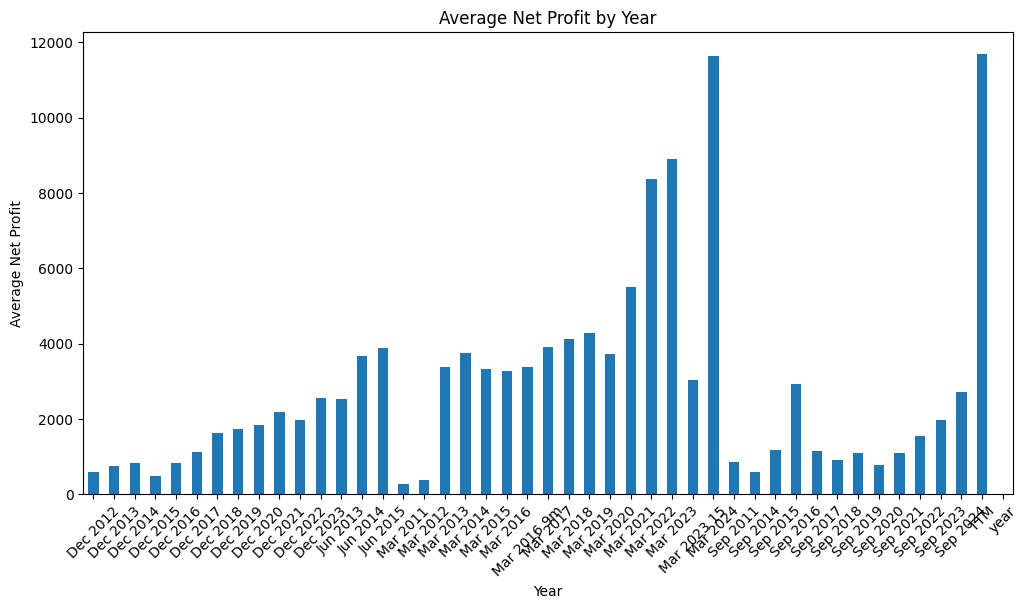

In [7]:
df_grouped = df.groupby('year')['net_profit'].mean()

plt.figure(figsize=(12,6))
df_grouped.plot(kind='bar')
plt.title("Average Net Profit by Year")
plt.xlabel("Year")
plt.ylabel("Average Net Profit")
plt.xticks(rotation=45)
plt.show()

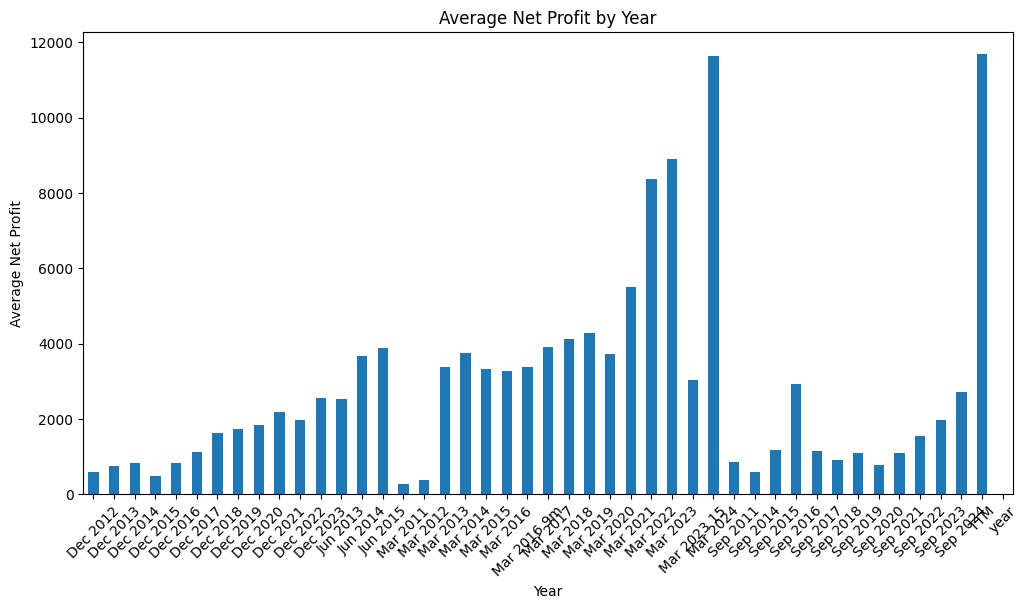

In [6]:
df['net_profit'] = pd.to_numeric(df['net_profit'], errors='coerce')

df_grouped = df.groupby('year')['net_profit'].mean()

plt.figure(figsize=(12,6))
df_grouped.plot(kind='bar')

plt.title("Average Net Profit by Year")
plt.xlabel("Year")
plt.ylabel("Average Net Profit")

plt.xticks(rotation=45)

plt.show()

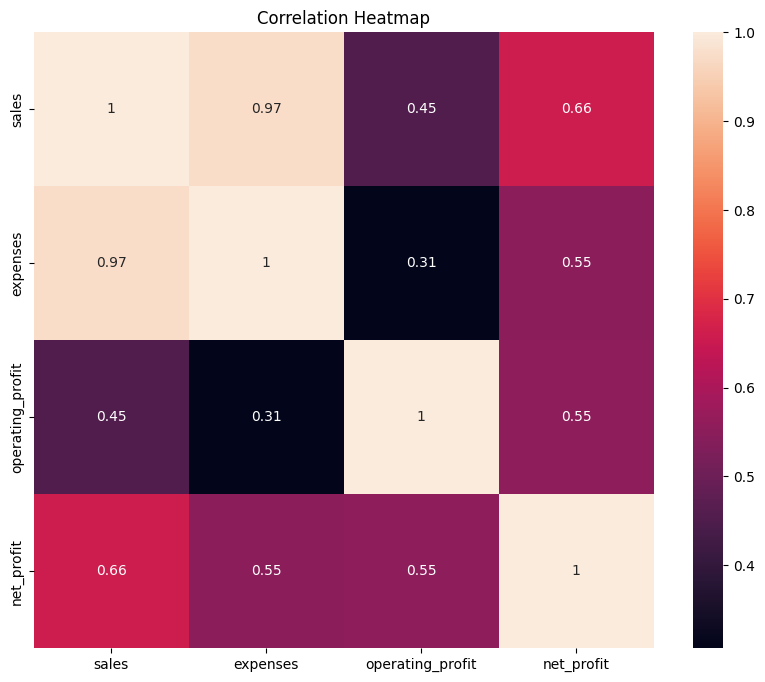

In [20]:
numeric_df = df[['sales','expenses','operating_profit','net_profit']].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [31]:
top_companies = df.sort_values(by='health_score', ascending=False)

top_companies[['company_id', 'year', 'health_score']].head(10)

,company_id,year,health_score
957,RELIANCE,TTM,175202.0
956,RELIANCE,Mar 2024,170265.1
955,RELIANCE,Mar 2023,159973.4
954,RELIANCE,Mar 2022,129182.8
636,IOC,Mar 2024,117595.4
736,LICI,TTM,113953.7
878,ONGC,Mar 2024,112833.9
508,HDFCBANK,TTM,112054.7
735,LICI,Mar 2024,110797.5
879,ONGC,TTM,108561.0


In [15]:
from scipy.stats import zscore

numeric_cols = ['sales','expenses','operating_profit','net_profit']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['z_score'] = zscore(df['net_profit'].fillna(0))

anomalies = df[abs(df['z_score']) > 3]

print("Total anomalies found:", len(anomalies))

anomalies[['company_id','year','net_profit','z_score']].head(20)

Total anomalies found: 33


,company_id,year,net_profit,z_score
217,BHARTIARTL,Mar 2020,-30664.0,-3.651253
338,COALINDIA,Mar 2024,37369.0,3.173607
505,HDFCBANK,Mar 2022,38151.0,3.252055
506,HDFCBANK,Mar 2023,46149.0,4.054390
507,HDFCBANK,Mar 2024,65446.0,5.990205
508,HDFCBANK,TTM,72168.0,6.664536
571,ICICIBANK,Mar 2024,46081.0,4.047568
572,ICICIBANK,TTM,52416.0,4.683076
636,IOC,Mar 2024,43161.0,3.754643
734,LICI,Mar 2023,35997.0,3.035973


In [30]:
numeric_cols = ['sales', 'expenses', 'opm_percentage', 'net_profit', 'operating_profit']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['health_score'] = (
    (df['net_profit'] * 0.4) +
    (df['operating_profit'] * 0.3) +
    (df['opm_percentage'] * 0.2) +
    (df['sales'] * 0.1)
)

print("Health score calculated successfully")
df[['company_id', 'year', 'health_score']].head()

Health score calculated successfully


,company_id,year,health_score
0,company_id,year,NaN
1,ABB,Dec 2012,286.3
2,ABB,Mar 2014,389.3
3,ABB,Mar 2015,416.9
4,ABB,Mar 2016,475.7


In [38]:
numeric_cols = ['sales', 'expenses', 'opm_percentage', 'net_profit', 'operating_profit']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['health_score'] = (
    (df['net_profit'] * 0.4) +
    (df['operating_profit'] * 0.3) +
    (df['opm_percentage'] * 0.2) +
    (df['sales'] * 0.1)
)

df[['company_id', 'year', 'health_score']].head()

,company_id,year,health_score
0,company_id,year,NaN
1,ABB,Dec 2012,286.3
2,ABB,Mar 2014,389.3
3,ABB,Mar 2015,416.9
4,ABB,Mar 2016,475.7


In [39]:
top_companies = df.sort_values(by='health_score', ascending=False)

top_companies[['company_id', 'year', 'health_score']].head(10)

,company_id,year,health_score
957,RELIANCE,TTM,175202.0
956,RELIANCE,Mar 2024,170265.1
955,RELIANCE,Mar 2023,159973.4
954,RELIANCE,Mar 2022,129182.8
636,IOC,Mar 2024,117595.4
736,LICI,TTM,113953.7
878,ONGC,Mar 2024,112833.9
508,HDFCBANK,TTM,112054.7
735,LICI,Mar 2024,110797.5
879,ONGC,TTM,108561.0


In [ ]:
top10 = top_companies.head(10)

plt.figure(figsize=(14,6))
plt.bar(top10['company_id'].astype(str), top10['health_score'])

plt.title("Top 10 Healthy Companies")
plt.xlabel("Company ID")
plt.ylabel("Health Score")

plt.xticks(rotation=45)

plt.show()

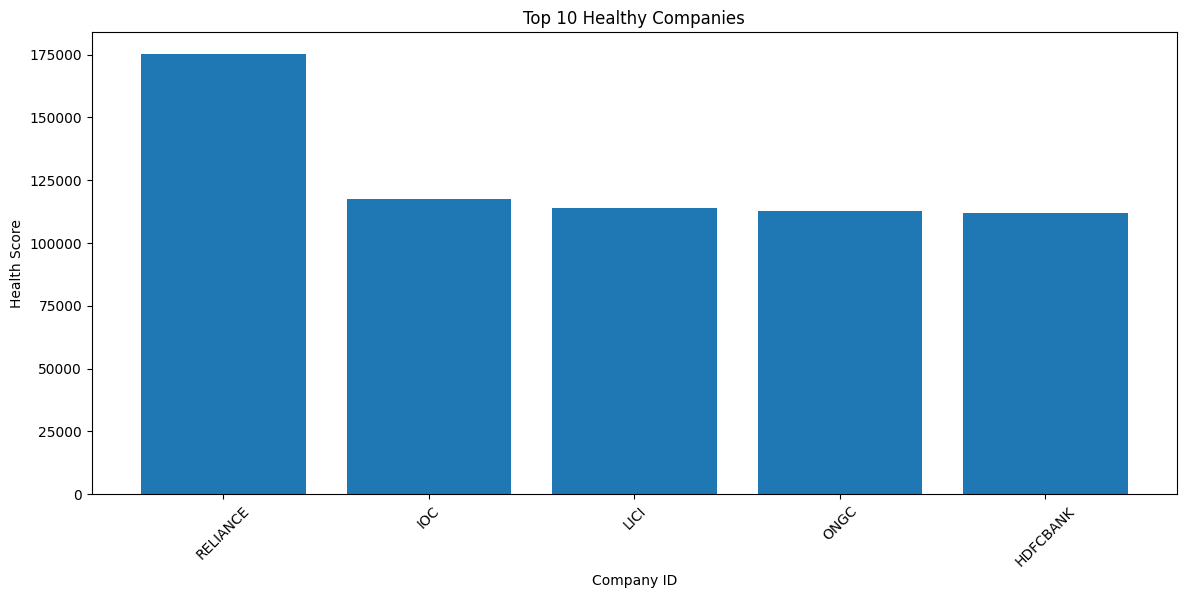

In [40]:
top10 = top_companies.head(10)

plt.figure(figsize=(14,6))
plt.bar(top10['company_id'].astype(str), top10['health_score'])

plt.title("Top 10 Healthy Companies")
plt.xlabel("Company ID")
plt.ylabel("Health Score")

plt.xticks(rotation=45)

plt.show()

In [41]:
top10.to_csv("top_healthy_companies.csv", index=False)

print("CSV exported successfully")

CSV exported successfully


In [42]:
from scipy.stats import zscore

df['z_score'] = zscore(df['net_profit'].fillna(0))

anomalies = df[abs(df['z_score']) > 3]

print("Total anomalies found:", len(anomalies))

anomalies[['company_id','year','net_profit','z_score']].head(20)

Total anomalies found: 33


,company_id,year,net_profit,z_score
217,BHARTIARTL,Mar 2020,-30664.0,-3.651253
338,COALINDIA,Mar 2024,37369.0,3.173607
505,HDFCBANK,Mar 2022,38151.0,3.252055
506,HDFCBANK,Mar 2023,46149.0,4.054390
507,HDFCBANK,Mar 2024,65446.0,5.990205
508,HDFCBANK,TTM,72168.0,6.664536
571,ICICIBANK,Mar 2024,46081.0,4.047568
572,ICICIBANK,TTM,52416.0,4.683076
636,IOC,Mar 2024,43161.0,3.754643
734,LICI,Mar 2023,35997.0,3.035973


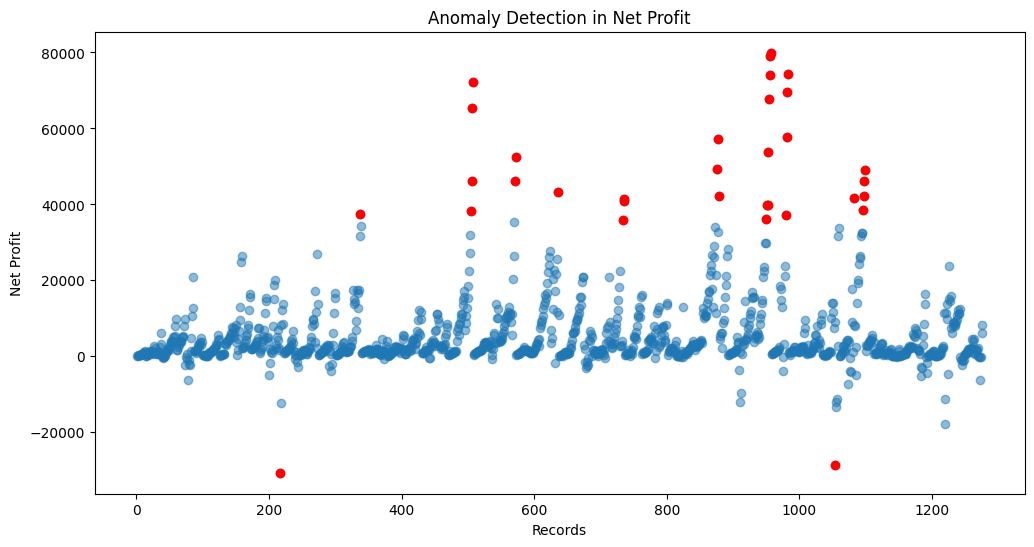

In [43]:
plt.figure(figsize=(12,6))

plt.scatter(df.index, df['net_profit'], alpha=0.5)

plt.scatter(
    anomalies.index,
    anomalies['net_profit'],
    color='red'
)

plt.title("Anomaly Detection in Net Profit")
plt.xlabel("Records")
plt.ylabel("Net Profit")

plt.show()

In [44]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [45]:
features = df[['sales','expenses','operating_profit','net_profit']]

features = features.fillna(0)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("Scaling Complete")

Scaling Complete


In [46]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(scaled_features)

print(df[['company_id','cluster']].head())

   company_id  cluster
0  company_id        0
1         ABB        0
2         ABB        0
3         ABB        0
4         ABB        0


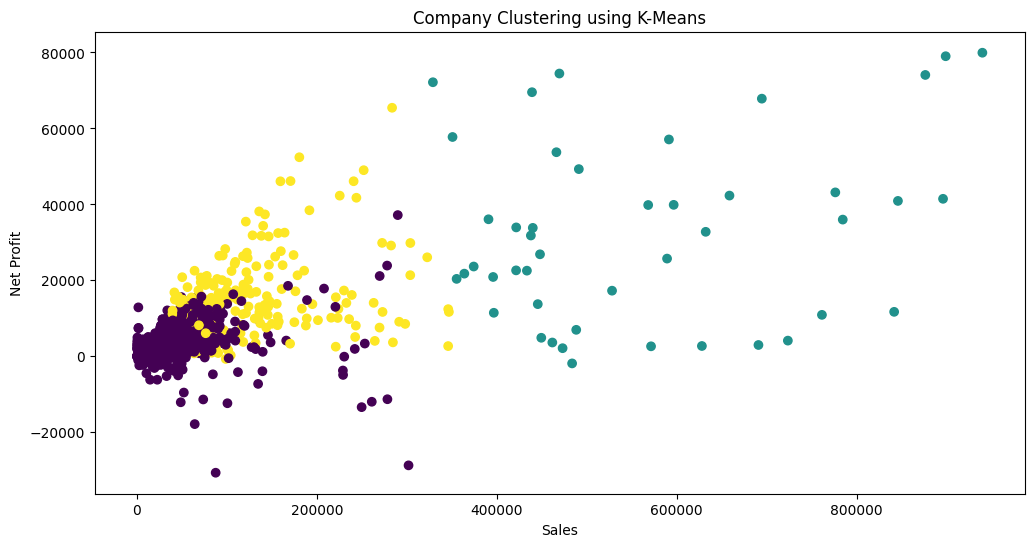

In [47]:
plt.figure(figsize=(12,6))

plt.scatter(
    df['sales'],
    df['net_profit'],
    c=df['cluster']
)

plt.xlabel("Sales")
plt.ylabel("Net Profit")
plt.title("Company Clustering using K-Means")

plt.show()

In [48]:
df.to_csv("final_company_analysis.csv", index=False)

print("Final CSV Exported Successfully")

Final CSV Exported Successfully
